# Tugas k-Nearest Neighbors (kNN) - Voice Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('voice.csv')

print('Ukuran data:', df.shape)
print('\nJumlah data per kelas:')
print(df['label'].value_counts())

df.head()

Ukuran data: (3168, 21)

Jumlah data per kelas:
label
male      1584
female    1584
Name: count, dtype: int64


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [3]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Percobaan Fitur

Jumlah fitur diuji dari 1 sampai seluruh fitur. Seleksi fitur menggunakan ANOVA F-test (`SelectKBest`), sedangkan evaluasi menggunakan 5-fold cross-validation. Standardisasi dilakukan di dalam pipeline karena kNN menggunakan perhitungan jarak.

In [4]:
jumlah_fitur = range(1, X.shape[1] + 1)
feature_accuracy = []

for n in jumlah_fitur:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=n)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy'
    ).mean()

    feature_accuracy.append(score)

best_n = int(np.argmax(feature_accuracy) + 1)

print('Jumlah fitur terbaik:', best_n)
print('CV accuracy terbaik:', round(max(feature_accuracy), 4))

Jumlah fitur terbaik: 6
CV accuracy terbaik: 0.9799


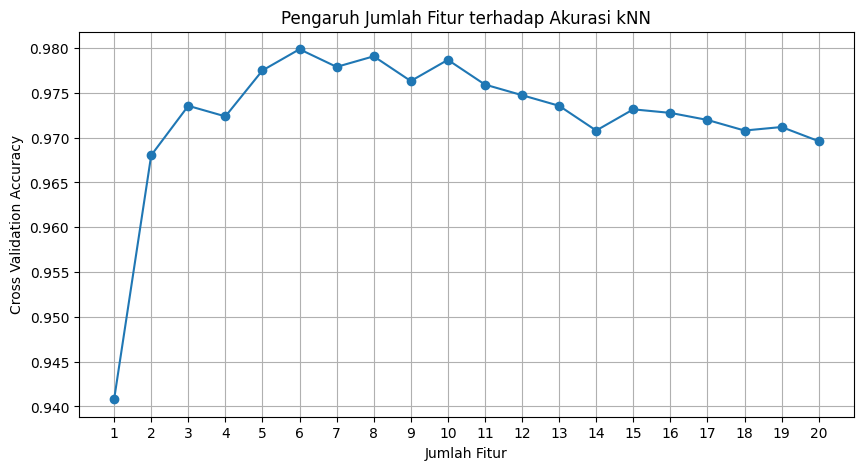

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(list(jumlah_fitur), feature_accuracy, marker='o')
plt.xlabel('Jumlah Fitur')
plt.ylabel('Cross Validation Accuracy')
plt.title('Pengaruh Jumlah Fitur terhadap Akurasi kNN')
plt.xticks(range(1, X.shape[1] + 1))
plt.grid()
plt.show()

In [6]:
selector = SelectKBest(score_func=f_classif, k=best_n)
selector.fit(X_train, y_train)

best_features = X_train.columns[selector.get_support()].tolist()

feature_scores = pd.DataFrame({
    'Fitur': X_train.columns,
    'F-Score': selector.scores_
}).sort_values('F-Score', ascending=False)

print('Fitur yang dipilih:')
print(best_features)

feature_scores

Fitur yang dipilih:
['sd', 'Q25', 'IQR', 'sp.ent', 'sfm', 'meanfun']


,Fitur,F-Score
12,meanfun,5697.873718
5,IQR,1566.488204
3,Q25,890.387180
8,sp.ent,794.113490
1,sd,750.762545
9,sfm,375.206538
11,centroid,324.436358
0,meanfreq,324.436358
2,median,218.279695
16,mindom,100.408598


## Percobaan Nilai k

Nilai `k` ganjil dari 1 sampai 31 diuji menggunakan fitur terbaik dari tahap sebelumnya. Nilai `k` terbaik ditentukan dari rata-rata akurasi 5-fold cross-validation.

In [7]:
X_train_selected = X_train[best_features]
X_test_selected = X_test[best_features]

k_values = list(range(1, 32, 2))

train_accuracy = []
test_accuracy = []
cv_accuracy = []

for k in k_values:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    cv_score = cross_val_score(
        model,
        X_train_selected,
        y_train,
        cv=cv,
        scoring='accuracy'
    ).mean()

    model.fit(X_train_selected, y_train)

    train_accuracy.append(model.score(X_train_selected, y_train))
    test_accuracy.append(model.score(X_test_selected, y_test))
    cv_accuracy.append(cv_score)

hasil_k = pd.DataFrame({
    'k': k_values,
    'Train Accuracy': train_accuracy,
    'Test Accuracy': test_accuracy,
    'CV Accuracy': cv_accuracy
})

hasil_k

,k,Train Accuracy,Test Accuracy,CV Accuracy
0,1,1.000000,0.985804,0.972768
1,3,0.986188,0.987382,0.981449
2,5,0.983425,0.985804,0.979872
3,7,0.982636,0.981073,0.978687
4,9,0.980663,0.977918,0.975924
5,11,0.980663,0.979495,0.975531
6,13,0.979084,0.977918,0.973952
7,15,0.978295,0.976341,0.973557
8,17,0.976717,0.977918,0.970399
9,19,0.974349,0.976341,0.970005


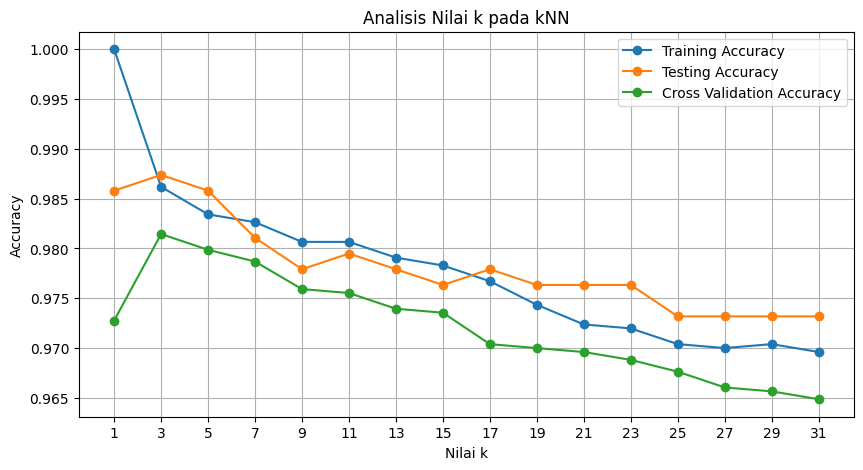

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_accuracy, marker='o', label='Training Accuracy')
plt.plot(k_values, test_accuracy, marker='o', label='Testing Accuracy')
plt.plot(k_values, cv_accuracy, marker='o', label='Cross Validation Accuracy')
plt.xlabel('Nilai k')
plt.ylabel('Accuracy')
plt.title('Analisis Nilai k pada kNN')
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.show()

In [9]:
best_index = int(np.argmax(cv_accuracy))
best_k = k_values[best_index]

print('k terbaik:', best_k)
print('CV Accuracy:', round(cv_accuracy[best_index], 4))
print('Test Accuracy:', round(test_accuracy[best_index], 4))

k terbaik: 3
CV Accuracy: 0.9814
Test Accuracy: 0.9874


## Model Final

In [10]:
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

final_model.fit(X_train_selected, y_train)
y_pred = final_model.predict(X_test_selected)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9874

Classification Report:
              precision    recall  f1-score   support

      female       0.99      0.99      0.99       317
        male       0.99      0.99      0.99       317

    accuracy                           0.99       634
   macro avg       0.99      0.99      0.99       634
weighted avg       0.99      0.99      0.99       634

Confusion Matrix:
[[313   4]
 [  4 313]]


## Kesimpulan

Berdasarkan percobaan pada `voice.csv`:

- Jumlah fitur terbaik adalah **6 fitur**.
- Fitur yang terpilih adalah **`sd`, `Q25`, `IQR`, `sp.ent`, `sfm`, dan `meanfun`**.
- Nilai **k terbaik adalah 3** berdasarkan rata-rata akurasi 5-fold cross-validation.
- Cross-validation accuracy pada `k = 3` sekitar **98,14%**.
- Testing accuracy pada `k = 3` sekitar **98,74%**.

`k = 1` menghasilkan akurasi training yang sangat tinggi karena model sangat mengikuti data latih. Pada `k = 3`, performa cross-validation menjadi lebih baik sehingga model memiliki kemampuan generalisasi yang lebih baik pada percobaan ini.